In [23]:
import pandas as pd

df = pd.read_csv('/content/DATA.csv')

print('First 5 rows of the DataFrame:')
print(df.head())

print('\nDataFrame Info:')
df.info()

print('\nDescriptive Statistics:')
print(df.describe())

First 5 rows of the DataFrame:
          Car       Model  Volume  Weight  CO2  Unnamed: 5
0      Toyota        Aygo    1000     790   99         NaN
1  Mitsubishi  Space Star    1200    1160   95         NaN
2       Skoda      Citigo    1000     929   95         NaN
3        Fiat         500     900     865   90         NaN
4        Mini      Cooper    1500    1140  105         NaN

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Car         36 non-null     object 
 1   Model       36 non-null     object 
 2   Volume      36 non-null     int64  
 3   Weight      36 non-null     int64  
 4   CO2         36 non-null     int64  
 5   Unnamed: 5  0 non-null      float64
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ KB

Descriptive Statistics:
            Volume       Weight         CO2  Unnamed: 5
count    36.000000    36.

Correlation Matrix:
          Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.753537  1.000000  0.552150
CO2     0.592082  0.552150  1.000000


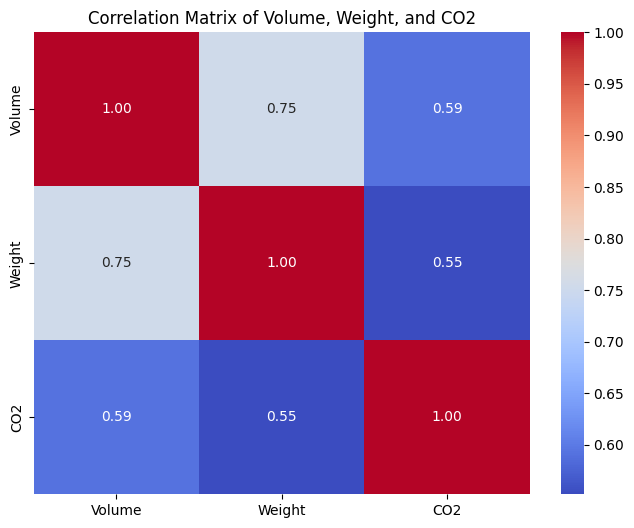

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for correlation analysis
correlation_data = df[['Volume', 'Weight', 'CO2']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

print('Correlation Matrix:')
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Volume, Weight, and CO2')
plt.show()

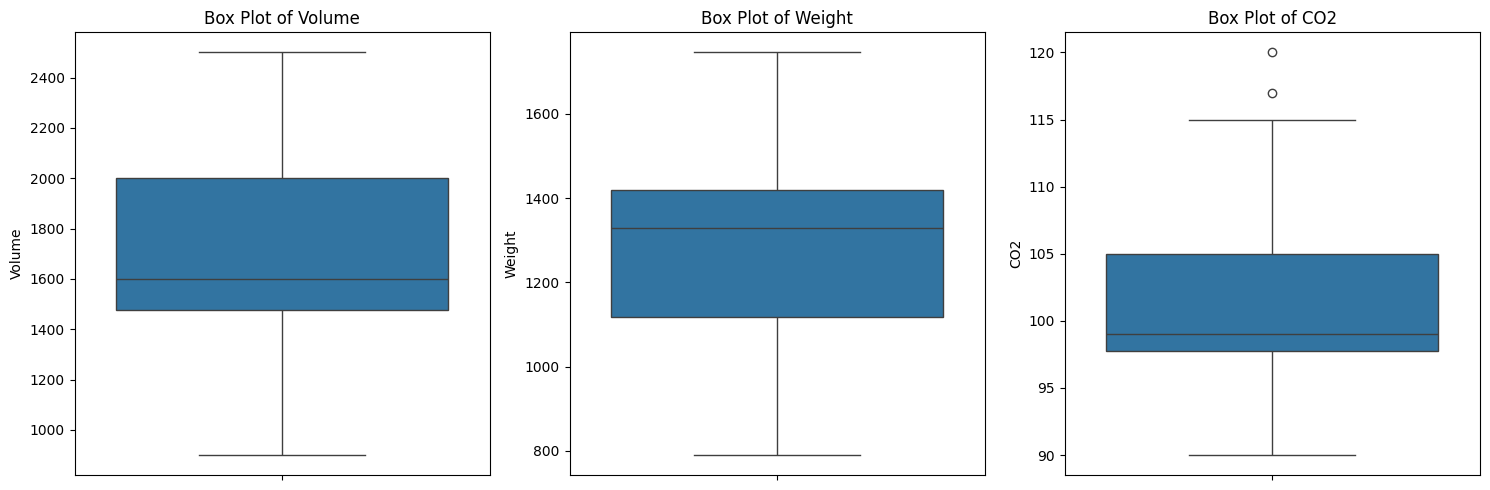

In [25]:
columns_to_plot = ['Volume', 'Weight', 'CO2']

plt.figure(figsize=(15, 5)) # Adjust figure size to accommodate multiple plots

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1) # Create subplots for better organization
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

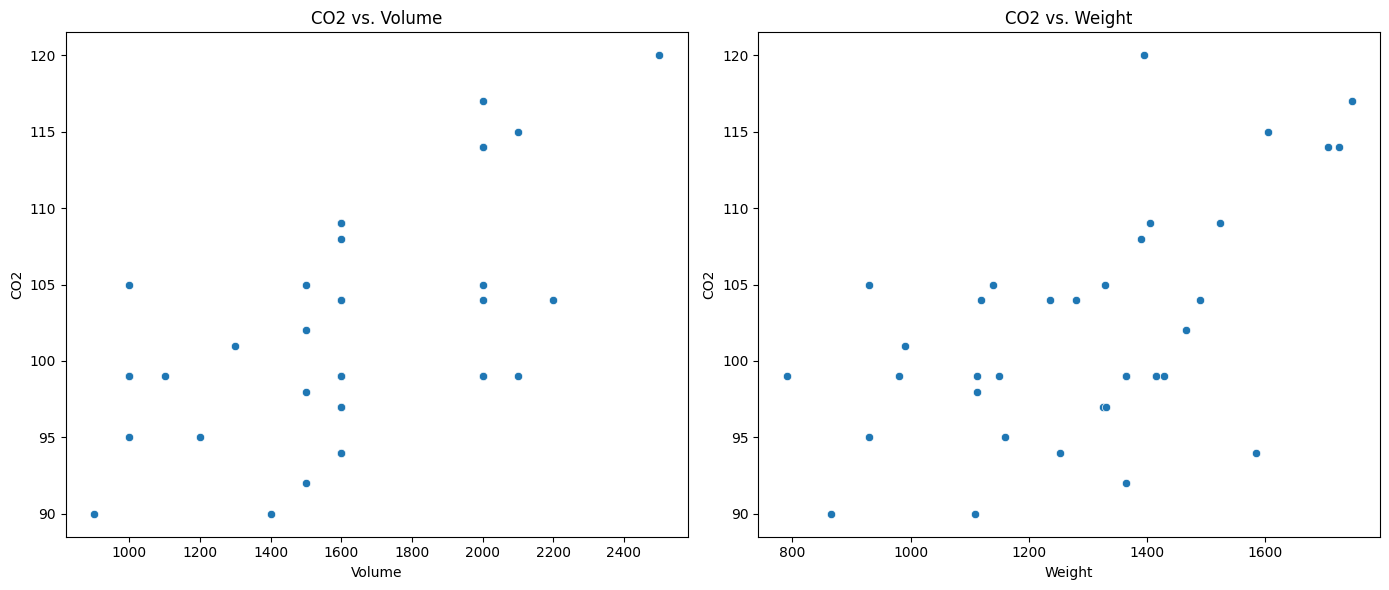

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for CO2 vs. VOLUME
sns.scatterplot(x='Volume', y='CO2', data=df, ax=axes[0])
axes[0].set_title('CO2 vs. Volume')
axes[0].set_xlabel('Volume')
axes[0].set_ylabel('CO2')

# Scatter plot for CO2 vs. WEIGHT
sns.scatterplot(x='Weight', y='CO2', data=df, ax=axes[1])
axes[1].set_title('CO2 vs. Weight')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('CO2')

plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Define independent variables X
X = df[['Volume', 'Weight']]

# 2. Define dependent variable y
y = df['CO2']

# 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

# 6. Instantiate a LinearRegression model
model = LinearRegression()

# 7. Train the model using the fit method
model.fit(X_train, y_train)

print('\nLinear Regression Model Trained Successfully.')

Shape of X_train: (28, 2)
Shape of X_test: (8, 2)
Shape of y_train: (28,)
Shape of y_test: (8,)

Linear Regression Model Trained Successfully.


Model Coefficients: [0.00428741 0.00804928]
Model Intercept: 84.21502006695282


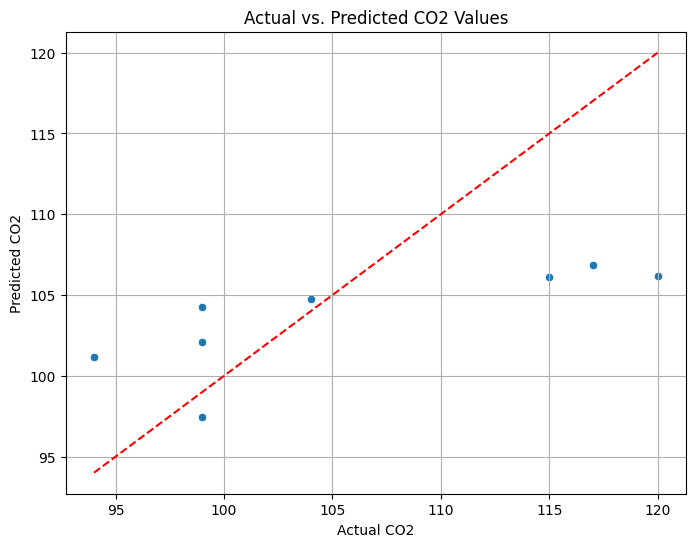

In [28]:
print('Model Coefficients:', model.coef_)
print('Model Intercept:', model.intercept_)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs. Predicted CO2 Values')
plt.xlabel('Actual CO2')
plt.ylabel('Predicted CO2')

# Plot a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.grid(True)
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 6.34
Mean Squared Error (MSE): 58.08
Root Mean Squared Error (RMSE): 7.62
